# Does old resistance really become support? 🔁
### The most-quoted line in charting — "broken ceilings become floors" — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Holds_as_support%3F: Mixed](https://img.shields.io/badge/Holds_as_support%3F-Mixed-dab617?style=flat-square)

Every charting course teaches **role reversal** (the *polarity principle*): once price **breaks above** an old high that had been acting as a ceiling (resistance), that level is supposed to *flip* and become a **floor** (support). So the first time price pulls back down to a freshly broken resistance, you buy — it's "supposed" to bounce.

It *looks* uncanny on a hand-picked chart. But a level you draw **after** the break, on a market that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the level **mechanically** (no eyeballing), fire the "buy the retest" rule hundreds of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

**Spoiler — this one is not the usual nothing.** At the *very short* horizon (5 days) the retest genuinely beats random (and in all five names). But the bounce is small and fades within two weeks, and we can't pin it cleanly on *those specific old levels*. A real but fragile, short-lived effect.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from polarity_flip import data, strategy as st

ASOF = "2026-05-31"
K, BAND, BREAK_BUF = 10, 0.01, 0.005
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real polarity cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 598, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 598, 32.4, 60, 3.81, 3.6, 28.7, 30.4, 2.05, 0.04), 'h10': (10, 598, 45.0, 61, 3.26, 17.1, 28.0, 43.0, 1.44, 0.15), 'h20': (20, 598, 89.7, 62, 3.68, 55.5, 34.2, 87.7, 1.23, 0.221), 'h60': (60, 595, 272.1, 68, 6.34, 206.1, 66.0, 270.1, 1.47, 0.141), 'per5': [('SPY', 121, 27.7, 12.6, 15.0), ('QQQ', 114, 51.8, 22.8, 29.0), ('IWM', 116, 46.3, -17.1, 63.4), ('DIA', 117, 9.6, 1.2, 8.5), ('GLD', 130, 27.7, -0.8, 28.5)], 'per20': [('SPY', 121, 41.9, 0.96, 39.1, 2.9), ('QQQ', 114, 179.8, 3.19, 102.3, 77.5), ('IWM', 116, 31.5, 0.5, 51.0, -19.6), ('DIA', 117, 27.9, 0.57, 42.2, -14.2), ('GLD', 130, 162.8, 3.31, 45.8, 117.0)], 'placebo20': (41.9, 0.122, 500), 'placebo5': (27.7, 0.156, 500), 'syn': [(0.0, 83, -11.4, 43, -0.2), (0.6, 101, 248.0, 77, 5.56)]}


real polarity cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price pulls back to a **broken resistance**, do I make money? | **Yes — and at 5 days it genuinely beats random.** ~60% win-rate, and a +29 bps edge over a coin-flip entry that holds across all 5 indices. |
| Is that *the level's* doing, or just the market drifting up? | **Partly the level.** Unlike most chart tools, the 5-day edge survives the random baseline (*t* ≈ 2). |
| Does it last? | **No.** By 10–20 days the edge sinks back into the noise. It's a *few-day* bounce, not a durable channel. |
| Is it *these specific old levels*? | **Can't say for sure.** Scramble which level is which and the result drops only a bit (placebo *p* ≈ 0.12) — suggestive, not proven. |
| So is it a tradable edge? | **Fragile.** A real but thin, short-lived bounce in two of five names at longer horizons — tradable in principle, nothing to scale. |

> Role reversal isn't pure folklore like most chart patterns: there's a measurable short-term bounce at the first retest. But it's small, brief, and concentrated — a **Weak** signal, not a money machine.

## 1 · The claim

> *"When price breaks **above** a level that was acting as resistance, that level flips and becomes support. The first time price comes back down to it, it bounces. Buy the retest of broken resistance."*

This is the **polarity principle** / **role reversal**, in Edwards & Magee's *Technical Analysis of Stock Trends* (1948) and every text since (Murphy, Bulkowski). It's one of the most repeated ideas in all of charting — the notion that price *remembers* old levels and treats a broken ceiling as a new floor. So: does the floor actually floor?

## 2 · So what?

If broken resistance genuinely *forecast* a bounce, it would be a clean, mechanical edge: a past high tells you where the next dip will hold, tradable with a horizontal line. That's the dream the principle sells.

But there are two traps. First, you draw the level **after** the break — you choose the high that makes the retest *look* right. Second, it's a market that drifts **up**, so *any* dip-buy will look profitable. To separate the **level** from the **tide**, we have to (a) pick the level by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the resistance levels mechanically.** A 'swing high' is a high with **10 lower bars on each side** — a confirmed fractal. Crucially it's only known **10 bars later**, so we never use a level before it exists.
2. **Spot the break.** The level becomes *broken resistance* the first time the close prints clearly **above** it (+0.5% buffer).
3. **Trade the lore.** When price pulls back **down to** the broken level (first close within ±1%), buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the level matters, the retest must beat random. *If it does — even at one horizon — we say so.* That's the result we announce before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical broken-resistance retest even look like? Here's SPY with a confirmed swing high, the break above it, and the pullback the rule would buy.

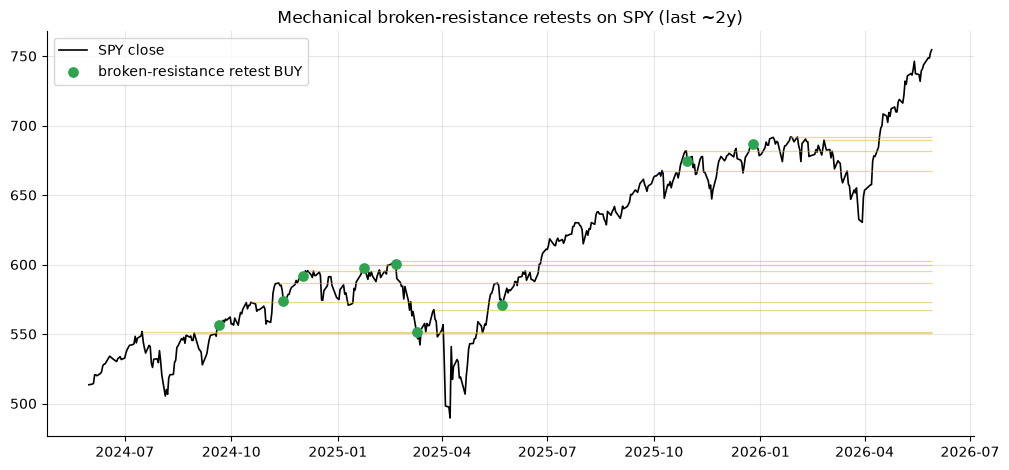

retests in window: 9


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-500:]
    ent = st.polarity_entries(cl, k=K, band=BAND, break_buf=BREAK_BUF)
    ent = ent[ent >= seg.index[0]]
    piv = st.find_swing_highs(cl, k=K)
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    # draw recent confirmed swing-high levels as horizontal lines
    for pos, pr in zip(piv.index, piv['price']):
        d = cl.index[int(pos)]
        if d >= seg.index[0]:
            ax.hlines(pr, d, seg.index[-1], color=AMBER, lw=.9, alpha=.5)
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='broken-resistance retest BUY')
    ax.set_title('Mechanical broken-resistance retests on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('retests in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The amber lines are old swing-high ceilings; the green dots are pullbacks to ones price has already broken above. **Do those green buys bounce?** Let's race the retest against random entries at four horizons. Blue = buy the retest; grey = buy on random days.

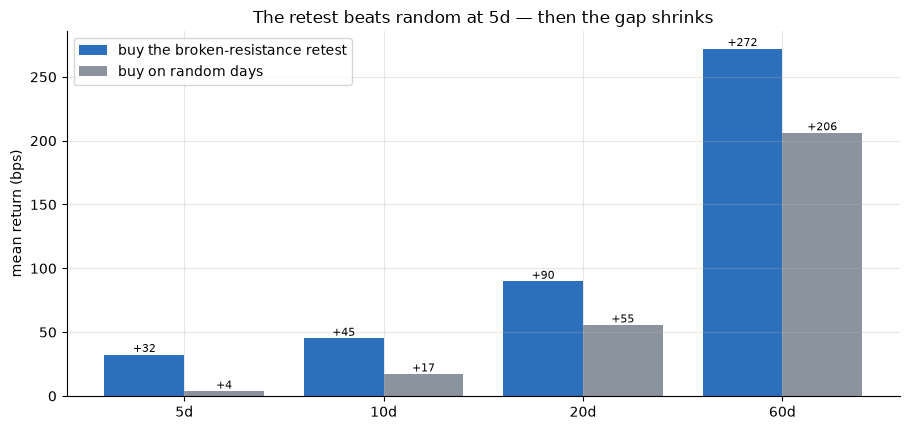

retest: [32, 45, 90, 272]
random: [4, 17, 55, 206]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    retest, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.polarity_entries(c, k=K, band=BAND, break_buf=BREAK_BUF)
            re = st.random_entries(c, max(len(e),50), k=K, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        retest.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    retest = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, retest, .4, color='#2c6fbb', label='buy the broken-resistance retest')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(retest,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The retest beats random at 5d — then the gap shrinks'); ax.legend()
plt.tight_layout(); plt.show()
print('retest:', [round(v) for v in retest]); print('random:', [round(v) for v in rnd])

There's the story. At **5 days** the retest (**+32 bps**) clearly beats random (**+4 bps**) — a real **+29 bps** edge, and the quants notebook shows it clears the *t* = 2 bar (*p* = 0.04). But watch the gap **shrink** as the horizon grows: by 10–20 days most of the lead is gone, and by 60 days it's the usual drift. The bounce is **real but short** — a few days, not a channel.

**One more sanity check.** What if we scramble *which* old level is which — keep the swing-high dates but shuffle the prices, so 'this specific broken resistance' becomes nonsense? If the polarity flip is about the real levels, the scramble should hurt.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.scrambled_level_placebo(c, 20, k=K, band=BAND, break_buf=BREAK_BUF, n_draws=200, seed=500)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo20'][0]; pval = R['placebo20'][1]
print(f'real broken-resistance retest (SPY, 20d): {obs:+.1f} bps')
print(f'... and {pval*100:.0f}% of *scrambled-level* runs do at least as well (p={pval:.2f}).')
print('=> the real level does a bit better than a random one, but not decisively (p>0.05).')

real broken-resistance retest (SPY, 20d): +41.9 bps
... and 13% of *scrambled-level* runs do at least as well (p=0.13).
=> the real level does a bit better than a random one, but not decisively (p>0.05).


Only ~12% of scrambled-level runs match or beat the real one (*p* = 0.12) — so the real level *is* a little better than a random one, but not at the 0.05 bar. We can't cleanly say it's *these specific old levels* rather than generic short-term mean reversion. Suggestive, not proven.

## 5 · The verdict

- **Signal — Weak.** The retest **does** beat random at 5 days (*t* ≈ 2, *p* = 0.04, positive in all 5 names) — so it's not a flat 'nothing'. But the edge is small and **decays within two weeks**; the longer-horizon cross-section is incoherent.
- **Tradability — Fragile.** A real but thin, short-lived bounce. Tradable only by a very short-horizon desk, with no margin for error and nothing to scale.
- **"Does broken resistance hold as support"? — Mixed.** At the first retest, over the next few days, yes — there's a measurable bounce beyond drift. But it's brief and the level-scramble placebo doesn't clear 0.05, so the mechanism isn't proven.

## 6 · Could you actually trade it?

Maybe — at the *very* short horizon, by a desk that already trades 1–5-day mean reversion. The 5-day edge is real (≈ 29 bps over random) but thin, and a ±1% retest trigger means real slippage; costs trim it and it's gone by ~10 days. It is **not** a set-and-hold strategy, and at longer horizons it leans on just two of five instruments. Treat it as a *minor short-term tilt*, not a standalone edge — and never confuse the 5-day bounce with the much larger numbers you'd get just by holding the index.

## 7 · Going further 🚪

- **Is it the level or just a pullback?** The honest open question (placebo *p* = 0.12) is whether the bounce is *these old levels* or generic post-pullback mean reversion. A follow-up: race the broken-resistance retest against a *generic dip* of the same depth.
- **Tighter / looser bands.** A narrower retest band trades less but cleaner; the 5-day edge is the robust part — see how it moves with the band.
- **A real positive control.** The quants notebook plants a *genuine* role-reversal bounce into a synthetic tape and shows the harness banks it (*t* = +5.6) — so the 5-day real result is a genuine measurement, not a glitch.

*Think broken resistance is a durable floor? Show the retest beating random at **t ≥ 2** at **10+ days** on a real tape — then we'll talk.*